<a href="https://colab.research.google.com/github/Trush564/Intellectlab7/blob/main/lab7Trush.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Завантажуємо створений файл
df = pd.read_csv('citrus.csv')
print("Файл завантажено успішно.")

Файл завантажено успішно.


In [3]:
# Виводимо перші 5 записів
print("Заголовок таблиці:")
display(df.head(5))

Заголовок таблиці:


,name,diameter,weight,red,green,blue
0,orange,7.750021,156.007073,157,92,10
1,grapefruit,11.611401,171.491554,151,68,3
2,grapefruit,12.096008,203.098301,147,64,7
3,orange,7.113126,161.388485,155,93,5
4,grapefruit,11.302945,226.402573,147,57,5


In [4]:
# Перевіряємо тип даних стовпця з назвами
print(f"Формат міток класів: {df['name'].dtype}")

Формат міток класів: object


In [5]:
# Визначаємо формат характеристик
print("Формат характеристик об’єктів:")
print(df.dtypes)

# Факторизація (заміна тексту на числа) за допомогою коду з методички
to_factor = ['name']
df[to_factor] = df[to_factor].apply(lambda col: pd.factorize(col, sort=True)[0])

print("\nДані після факторизації:")
display(df.head(5))

Формат характеристик об’єктів:
name         object
diameter    float64
weight      float64
red           int64
green         int64
blue          int64
dtype: object

Дані після факторизації:


,name,diameter,weight,red,green,blue
0,1,7.750021,156.007073,157,92,10
1,0,11.611401,171.491554,151,68,3
2,0,12.096008,203.098301,147,64,7
3,1,7.113126,161.388485,155,93,5
4,0,11.302945,226.402573,147,57,5


In [6]:
# Рахуємо кількість кожного класу
counts = df['name'].value_counts()
print("Кількість об'єктів кожного класу:")
print(counts)
print("\nКласи збалансовані, оскільки містять однакову кількість зразків.")

Кількість об'єктів кожного класу:
name
1    5000
0    5000
Name: count, dtype: int64

Класи збалансовані, оскільки містять однакову кількість зразків.


In [7]:
from tensorflow.keras.utils import to_categorical

# Створюємо X (ознаки) та Y (ціль)
X = df.drop('name', axis=1).values
Y = df['name'].values

# Перетворюємо Y у формат One Hot Encoding
Y_one_hot = to_categorical(Y)

print("Мітки класів перетворено до One Hot Encoding.")
print(f"Приклад першого запису Y: {Y_one_hot[0]}")

Мітки класів перетворено до One Hot Encoding.
Приклад першого запису Y: [0. 1.]


In [8]:
from sklearn.model_selection import train_test_split

# Розбиваємо у співвідношенні 80% на 20%
X_train, X_test, Y_train, Y_test = train_test_split(X, Y_one_hot, test_size=0.2, random_state=42)

print(f"Розмір навчальної множини: {len(X_train)}")
print(f"Розмір тестової множини: {len(X_test)}")

Розмір навчальної множини: 8000
Розмір тестової множини: 2000


In [9]:
from sklearn.preprocessing import StandardScaler

# Масштабуємо дані для кращої роботи нейромережі
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Предиктори стандартизовано.")

Предиктори стандартизовано.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Описуємо структуру мережі
model = Sequential([
    Dense(12, input_dim=5, activation='relu'), # Вхідний шар (5 ознак)
    Dense(8, activation='relu'),               # Прихований шар
    Dense(2, activation='softmax')             # Вихідний шар (2 класи)
])

# Обираємо оптимізатор та метрики
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Архітектуру моделі створено.")
model.summary()

Архітектуру моделі створено.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194 (776.00 B)

 Trainable params: 194 (776.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Запускаємо навчання
print("Початок навчання...")
history = model.fit(X_train, Y_train, epochs=40, batch_size=32, verbose=1)
print("Навчання завершено.")

Початок навчання...
Epoch 1/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9309 - loss: 0.2312
Epoch 2/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9970 - loss: 0.0228
Epoch 3/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9981 - loss: 0.0098
Epoch 4/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9986 - loss: 0.0063
Epoch 5/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9989 - loss: 0.0047
Epoch 6/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9990 - loss: 0.0037
Epoch 7/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9990 - loss: 0.0032
Epoch 8/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9992 - loss: 0.0027
Epoch 9/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9992 - loss: 0.0025
Epoch 10/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0023
Epoch 11/40
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9994 - loss: 0.0021
Epoch 12/40
250/250 ━━━━━━━━━━━━

In [12]:
# Перевіряємо модель на даних, які вона ще не бачила
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Точність на тестовій множині: {accuracy*100:.2f}%")

Точність на тестовій множині: 99.95%


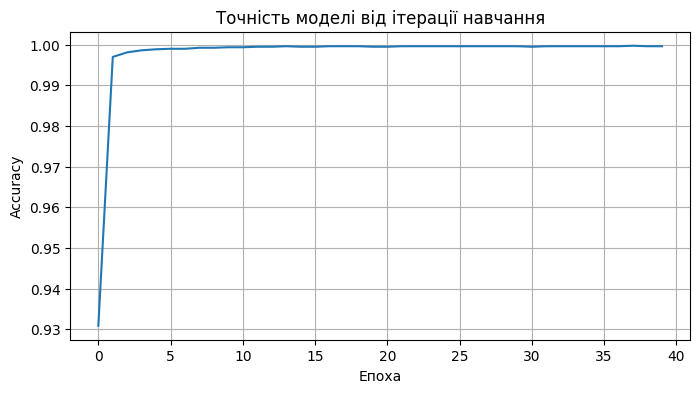

In [13]:
import matplotlib.pyplot as plt

# Графік залежності Accuracy від епохи
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'])
plt.title('Точність моделі від ітерації навчання')
plt.ylabel('Accuracy')
plt.xlabel('Епоха')
plt.grid(True)
plt.show()

In [14]:
import numpy as np

# Беремо випадковий зразок з тестової вибірки
random_idx = np.random.randint(0, len(X_test))
sample = X_test[random_idx:random_idx+1]

# Робимо прогноз
pred = model.predict(sample)
predicted_class = np.argmax(pred)
probability = np.max(pred) * 100

# Визначаємо назву класу (враховуючи факторизацію)
# Якщо orange=1, grapefruit=0
labels = {1: 'апельсин', 0: 'грейпфрут'}

print(f"\nРезультат: «Передбачено клас {labels[predicted_class]} з достовірністю {probability:.2f}%»")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Результат: «Передбачено клас грейпфрут з достовірністю 100.00%»
